# **1. Data Preperation**

In [1]:
import pandas as pd

df = pd.read_csv("malicious_phish.csv")
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [2]:
print(df.shape)
print(df.columns)
print(df['type'].value_counts())

(541118, 2)
Index(['url', 'type'], dtype='object')
type
benign        380199
defacement     96457
phishing       46010
malware        18451
mal                1
Name: count, dtype: int64


In [3]:
# data cleaning
df = df.dropna(subset=["url", "type"])

df["url"] = df["url"].astype(str).str.strip().str.lower()
df["type"] = df["type"].astype(str).str.strip().str.lower()

df = df[df["url"] != ""]
df = df.drop_duplicates(subset=["url"])

print("Shape after cleaning:", df.shape)

Shape after cleaning: (531009, 2)


In [4]:
# turn it into a binary classification problem
def to_binary_label(x):
  if x == "benign":
    return "benign"
  else:
    return "malicious"

df["binary_type"] = df["type"].apply(to_binary_label)

class_counts = df["binary_type"].value_counts()
print(class_counts)
df.head()

binary_type
benign       380178
malicious    150831
Name: count, dtype: int64


,url,type,binary_type
0,br-icloud.com.br,phishing,malicious
1,mp3raid.com/music/krizz_kaliko.html,benign,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement,malicious
4,http://adventure-nicaragua.net/index.php?optio...,defacement,malicious


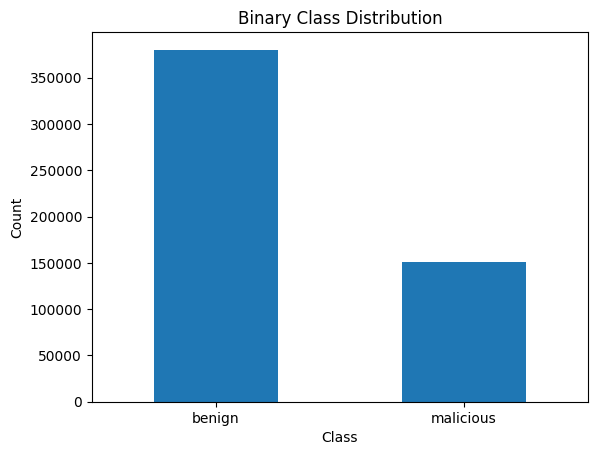

In [5]:
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")
plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [6]:
# Split the data. 70% training, 15% validation, 15% test.
from sklearn.model_selection import train_test_split

X = df["url"]
y = df["binary_type"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 371706
Validation size: 79651
Test size: 79652


# **2. Baseline model**

In [7]:
# Extract features from raw urls
import re
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def extract_features(url):
  url = str(url)
  return {
      "url_length": len(url),
      "digit_count": sum(c.isdigit() for c in url),
      "dot_count": url.count("."),
      "slash_count": url.count("/"),
      "hyphen_count": url.count("-"),
      "underscore_count": url.count("_"),
      "question_count": url.count("?"),
      "equal_count": url.count("="),
      "ampersand_count": url.count("&"),
      "at_count": url.count("@"),
      "has_https": int("https" in url),
      "has_http": int("http" in url),
      "has_login": int("login" in url),
      "has_verify": int("verify" in url),
      "has_account": int("account" in url),
      "has_secure": int("secure" in url),
      "has_ip_pattern": int(bool(re.search(r"\d+\.\d+\.\d+\.\d+", url))),
    }

X_train_feat = pd.DataFrame([extract_features(u) for u in X_train])
X_val_feat = pd.DataFrame([extract_features(u) for u in X_val])
X_test_feat = pd.DataFrame([extract_features(u) for u in X_test])

X_train_feat.head()

,url_length,digit_count,dot_count,slash_count,hyphen_count,underscore_count,question_count,equal_count,ampersand_count,at_count,has_https,has_http,has_login,has_verify,has_account,has_secure,has_ip_pattern
0,39,0,1,4,0,0,0,0,0,0,0,0,0,0,0,0,0
1,14,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,38,0,2,2,0,2,0,0,0,0,0,0,0,0,0,0,0
3,58,6,4,4,0,0,0,0,0,0,0,0,0,0,0,0,0
4,32,6,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print(label_encoder.classes_)

['benign' 'malicious']


In [9]:
# train the model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_feat, y_train_enc)

# predict on validation and test
y_val_pred_base = baseline_model.predict(X_val_feat)
y_test_pred_base = baseline_model.predict(X_test_feat)

# evaluation
def print_metrics(y_true, y_pred, name):
  print("----", name, "----")
  print("Accuracy:", accuracy_score(y_true, y_pred))
  print("Precision:", precision_score(y_true, y_pred))
  print("Recall:", recall_score(y_true, y_pred))
  print("F1:", f1_score(y_true, y_pred))
  print("Confusion matrix:")
  print(confusion_matrix(y_true, y_pred))
  print()

print_metrics(y_val_enc, y_val_pred_base, "Baseline Validation")
print_metrics(y_test_enc, y_test_pred_base, "Baseline Test")

---- Baseline Validation ----
Accuracy: 0.9202395450151285
Precision: 0.9070803102326745
Recall: 0.8012729844413012
F1: 0.8509000445915182
Confusion matrix:
[[55170  1857]
 [ 4496 18128]]

---- Baseline Test ----
Accuracy: 0.9209687139054888
Precision: 0.9076385421867199
Recall: 0.8035359116022099
F1: 0.85242058375337
Confusion matrix:
[[55177  1850]
 [ 4445 18180]]



In [10]:
baseline_results = pd.DataFrame({
    "url": X_test.reset_index(drop=True),
    "true_type": label_encoder.inverse_transform(y_test_enc),
    "pred_type": label_encoder.inverse_transform(y_test_pred_base)
})

print(baseline_results.sample(10, random_state=42))

                                                     url  true_type  pred_type
36338    http://www.majestic.com.tr/index.html?ui=mobile  malicious  malicious
53613  worthpoint.com/worthopedia/hamilton-standard-p...     benign     benign
7431                  http://sibrc.org/news/news_52.html  malicious  malicious
10955  http://www.barric.co.uk/news/barric-to-provide...  malicious  malicious
39320  siteadvisor.com/sites/tou.tv?pip=false&premium...     benign     benign
10329              stpaullp.org/lamplighter/calendar.htm     benign     benign
19593          linkedin.com/pub/alex-tagliani/14/18a/862     benign     benign
7158                    flagspot.net/flags/si-munic.html     benign     benign
55532                              myspace.com/oscar.lua     benign     benign
4569            marketwatch.com/investing/stock/dst/news     benign     benign


# **3. Primary Model: Character-level CNN**

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 200

tokenizer = Tokenizer(char_level=True, lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)
print("Training shape:", X_train_pad.shape)

Vocabulary size: 179
Training shape: (371706, 200)


In [12]:
# CNN model
cnn_model = Sequential([
    tf.keras.Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_len),
    Conv1D(filters=64, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │         5,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,145 (70.88 KB)

 Trainable params: 18,145 (70.88 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# training
history = cnn_model.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=5,
    batch_size=64
)

# predict
y_test_prob_cnn = cnn_model.predict(X_test_pad)
y_test_pred_cnn = (y_test_prob_cnn > 0.5).astype(int).flatten()

# evaluate
print_metrics(y_test_enc, y_test_pred_cnn, "CNN Test")

Epoch 1/5
5808/5808 ━━━━━━━━━━━━━━━━━━━━ 164s 28ms/step - accuracy: 0.9886 - loss: 0.0310 - val_accuracy: 0.9955 - val_loss: 0.0120
Epoch 2/5
5808/5808 ━━━━━━━━━━━━━━━━━━━━ 168s 29ms/step - accuracy: 0.9970 - loss: 0.0093 - val_accuracy: 0.9979 - val_loss: 0.0066
Epoch 3/5
5808/5808 ━━━━━━━━━━━━━━━━━━━━ 177s 31ms/step - accuracy: 0.9980 - loss: 0.0062 - val_accuracy: 0.9987 - val_loss: 0.0042
Epoch 4/5
5808/5808 ━━━━━━━━━━━━━━━━━━━━ 191s 29ms/step - accuracy: 0.9983 - loss: 0.0051 - val_accuracy: 0.9986 - val_loss: 0.0047
Epoch 5/5
5808/5808 ━━━━━━━━━━━━━━━━━━━━ 163s 28ms/step - accuracy: 0.9987 - loss: 0.0042 - val_accuracy: 0.9990 - val_loss: 0.0031
2490/2490 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step
---- CNN Test ----
Accuracy: 0.9988575302566163
Precision: 0.9982752520785424
Recall: 0.9977016574585635
F1: 0.9979883723500674
Confusion matrix:
[[56988    39]
 [   52 22573]]



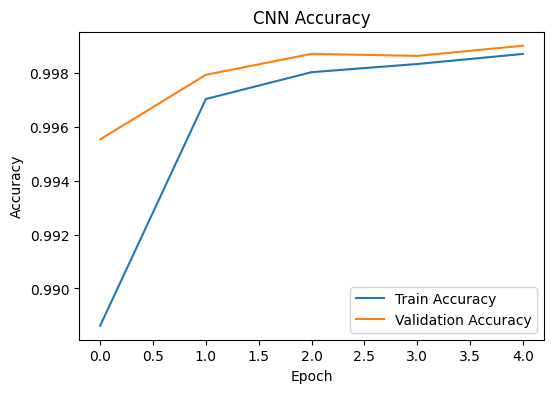

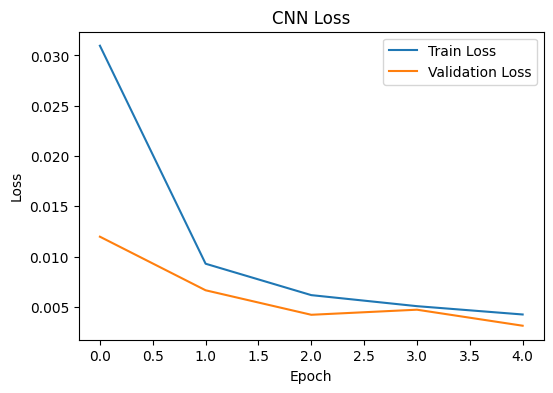

In [14]:
# accuracy curve
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# loss curve
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
cnn_results = pd.DataFrame({
    "url": X_test.reset_index(drop=True),
    "true_type": label_encoder.inverse_transform(y_test_enc),
    "pred_type": label_encoder.inverse_transform(y_test_pred_cnn)
})

print(cnn_results.sample(10, random_state=42))

                                                     url  true_type  pred_type
36338    http://www.majestic.com.tr/index.html?ui=mobile  malicious  malicious
53613  worthpoint.com/worthopedia/hamilton-standard-p...     benign     benign
7431                  http://sibrc.org/news/news_52.html  malicious  malicious
10955  http://www.barric.co.uk/news/barric-to-provide...  malicious  malicious
39320  siteadvisor.com/sites/tou.tv?pip=false&premium...     benign     benign
10329              stpaullp.org/lamplighter/calendar.htm     benign     benign
19593          linkedin.com/pub/alex-tagliani/14/18a/862     benign     benign
7158                    flagspot.net/flags/si-munic.html     benign     benign
55532                              myspace.com/oscar.lua     benign     benign
4569            marketwatch.com/investing/stock/dst/news     benign     benign


In [16]:
# correct predictions
cnn_correct = cnn_results[cnn_results["true_type"] == cnn_results["pred_type"]]
print("Number of correct predictions:", len(cnn_correct))
print(cnn_correct.sample(5, random_state=42))

Number of correct predictions: 79561
                                                     url  true_type  pred_type
19647         facebook.com/pages/arashic/109392049080798     benign     benign
61533                                 menloenergyllc.com  malicious  malicious
61907  http://distractify.com/post/related/id/5550ec6...     benign     benign
47926                farmeralfalfa.tripod.com/video.html     benign     benign
4254   plaxo.com/directory/profile/231929023546/865c4...     benign     benign


In [17]:
# wrong predictions
cnn_wrong = cnn_results[cnn_results["true_type"] != cnn_results["pred_type"]]
print("Number of wrong predictions:", len(cnn_wrong))
print(cnn_wrong.sample(min(5, len(cnn_wrong)), random_state=42))

Number of wrong predictions: 91
                                                     url  true_type  pred_type
41948  http://katproxy.com/bob-james-obsession-flac-m...     benign  malicious
28543  https://globalnetinternet.com/online_islemler_...  malicious     benign
54354  http://vz.ru/redir/?source=vz_teasers_main2&id...     benign  malicious
77258  http://likemag.com/sites/default/files/css/css...     benign  malicious
415    https://oneplus.net/ca_en/customer/account/log...     benign  malicious


# **4. Model comparison and Summary**

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_df = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "Character-level CNN"],
    "Accuracy": [
        accuracy_score(y_test_enc, y_test_pred_base),
        accuracy_score(y_test_enc, y_test_pred_cnn)
    ],
    "Precision": [
        precision_score(y_test_enc, y_test_pred_base),
        precision_score(y_test_enc, y_test_pred_cnn)
    ],
    "Recall": [
        recall_score(y_test_enc, y_test_pred_base),
        recall_score(y_test_enc, y_test_pred_cnn)
    ],
    "F1": [
        f1_score(y_test_enc, y_test_pred_base),
        f1_score(y_test_enc, y_test_pred_cnn)
    ]
})

print(comparison_df)

                          Model  Accuracy  Precision    Recall        F1
0  Baseline Logistic Regression  0.920969   0.907639  0.803536  0.852421
1           Character-level CNN  0.998858   0.998275  0.997702  0.997988


In [19]:
# Summary

print("Total cleaned samples:", len(df))
print("\nBinary class counts:")
print(df["binary_type"].value_counts())

print("\nTrain / Validation / Test sizes:")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\n BASELINE TEST METRICS")
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred_base))
print("Precision:", precision_score(y_test_enc, y_test_pred_base))
print("Recall:", recall_score(y_test_enc, y_test_pred_base))
print("F1:", f1_score(y_test_enc, y_test_pred_base))

print("\n CNN TEST METRICS")
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred_cnn))
print("Precision:", precision_score(y_test_enc, y_test_pred_cnn))
print("Recall:", recall_score(y_test_enc, y_test_pred_cnn))
print("F1:", f1_score(y_test_enc, y_test_pred_cnn))

print("\n CNN MODEL INFO")
print("Vocabulary size:", vocab_size)
print("Max URL length:", max_len)

Total cleaned samples: 531009

Binary class counts:
binary_type
benign       380178
malicious    150831
Name: count, dtype: int64

Train / Validation / Test sizes:
Train: 371706
Validation: 79651
Test: 79652

 BASELINE TEST METRICS
Accuracy: 0.9209687139054888
Precision: 0.9076385421867199
Recall: 0.8035359116022099
F1: 0.85242058375337

 CNN TEST METRICS
Accuracy: 0.9988575302566163
Precision: 0.9982752520785424
Recall: 0.9977016574585635
F1: 0.9979883723500674

 CNN MODEL INFO
Vocabulary size: 179
Max URL length: 200


In [20]:
# save results
comparison_df.to_csv("model_comparison.csv", index=False)
print("Saved: model_comparison.csv")

cnn_results.to_csv("cnn_results_full.csv", index=False)
print("Saved: cnn_results_full.csv")

Saved: model_comparison.csv
Saved: cnn_results_full.csv
